In [117]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates
import cmocean as cmo 
import matplotlib as mpl 
# get dates

# Create object 
class ModelResult:
    def __init__(self, fn, start_date, end_date, isave):
        self.ds = xr.open_dataset(fn, decode_timedelta=False)
        self.nt = len(self.ds.time.values)
        self.start_day = pd.to_datetime(start_date)
        self.end_day = pd.to_datetime(end_date)
        self.dates = pd.date_range(start_date, end_date, freq="10s")
        self.dates = self.dates[::isave]
        self.dates = self.dates[0:self.nt]
        print("There are %d saved profiles in this model..." % self.nt)


isave = 360

# model = xr.open_dataset("2024.nc")


# Format days 
# start_day = 6
# end_day   = 30
# start_date = "2024-08-%02d 00:00" % start_day
# end_date   = "2024-08-%02d 00:00" % end_day
# nt = len(model.time.values)
# dates = pd.date_range(start_date, end_date, freq="10s")
# dates = dates[::isave]
# dates = dates[0:nt]

colors = ["#a4c639", "#73c2fb", "#d1001c"]


m2022 = ModelResult("2022.nc", "2022-06-02 00:00", "2022-06-29 00:00", isave)
m2024 = ModelResult("2024_2.nc", "2024-08-06 00:00", "2024-08-30 00:00", isave)

def format_date_ax(ax, days=2):
    """Format the x-axis of a plot with date labels."""
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=days))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%d %H:%M"))
    ax.grid(alpha=0.25, which="both")
    # plt.setp(ax.get_xticklabels(), rotation=10, ha='right')   

def add_colorbar(fig, c):
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    cb = fig.colorbar(c, cax=cbar_ax, shrink=0.4)
    return cb 


There are 527 saved profiles in this model...
There are 527 saved profiles in this model...


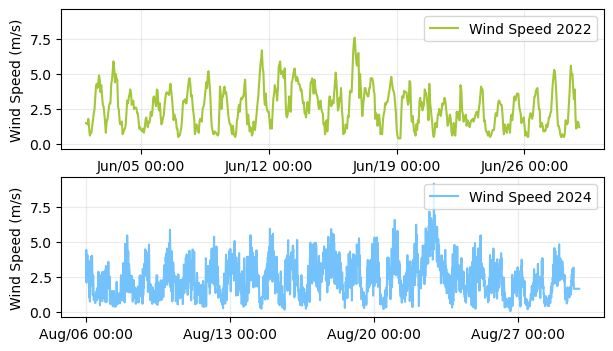

In [118]:
# Compare wind + heat forcings 
wind_2022 = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2022/june2-29/wind.csv")
wind_2024 = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/august6-30/wind.csv")
heat_2022 = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2022/june2-29/heat_flux.csv")
heat_2024 = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/august6-30/heat_flux.csv")

fig, axs = plt.subplots(2,1, figsize=(7, 4), sharex=False, sharey=True)
axs[0].plot(pd.to_datetime(wind_2022["time"]), wind_2022["WindSpeed"], label="Wind Speed 2022", color=colors[0])
axs[1].plot(pd.to_datetime(wind_2024["time"]), wind_2024["WindSpeed"], label="Wind Speed 2024", color=colors[1])
for ax in axs:
    format_date_ax(ax, days=7)
    ax.legend(loc="upper right") 
    ax.set_ylabel("Wind Speed (m/s)")




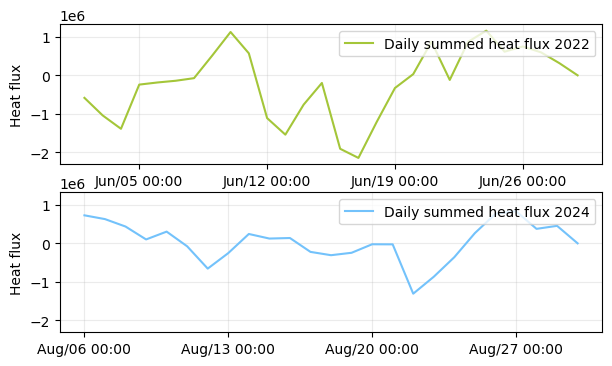

In [119]:
fig, axs = plt.subplots(2,1, figsize=(7, 4), sharex=False, sharey=True)

heat_2022["time"] = pd.to_datetime(heat_2022["time"])
heat_2024["time"] = pd.to_datetime(heat_2024["time"])

heat_2022_daily = heat_2022[["sw_in", "surface"]].groupby(heat_2022["time"].dt.date).sum()
heat_2024_daily = heat_2024[["sw_in", "surface"]].groupby(heat_2024["time"].dt.date).sum()

axs[0].plot(heat_2022_daily.index, heat_2022_daily["sw_in"] + heat_2022_daily["surface"], label="Daily summed heat flux 2022", color=colors[0])
axs[1].plot(heat_2024_daily.index, heat_2024_daily["sw_in"] + heat_2024_daily["surface"], label="Daily summed heat flux 2024", color=colors[1])
for ax in axs:
    format_date_ax(ax, days=7)
    ax.legend(loc="upper right") 
    ax.set_ylabel("Heat flux")

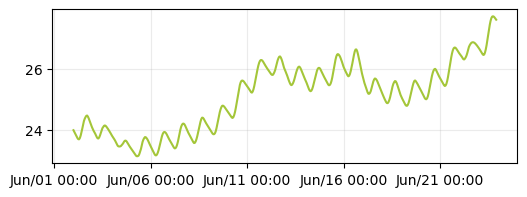

In [120]:
fig2, ax2 = plt.subplots( figsize=(6, 2))
ax2.plot(m2022.dates, m2022.ds['C'].mean(dim='z'), color=colors[0])
format_date_ax(ax2, days=5)

Text(0, 0.5, 'Depth (m)')

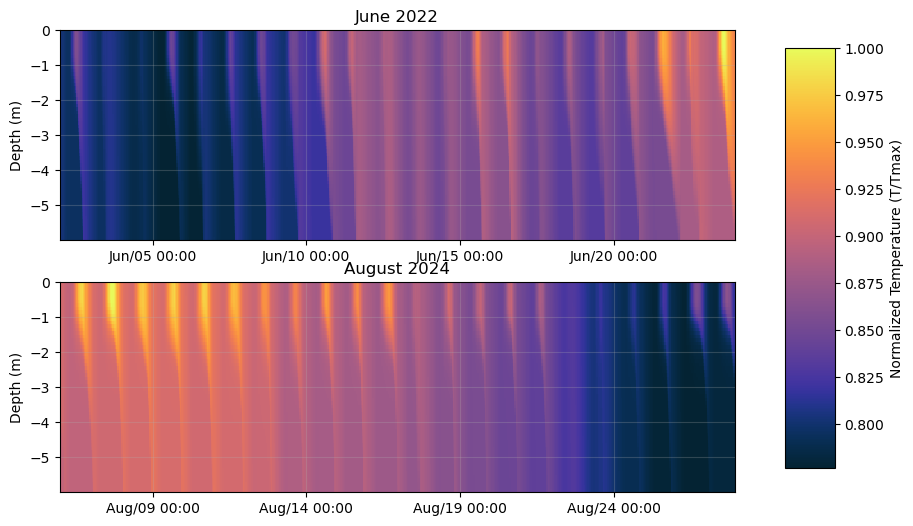

In [128]:
fig, axs = plt.subplots(figsize=(10, 6), nrows=2, sharey=True, sharex=False)

maxC = max(m2022.ds['C'].values.ravel())

c1 = axs[0].pcolormesh(m2022.dates,-m2022.ds.z, m2022.ds['C'].values.T/maxC,  cmap=cmo.cm.thermal) #, vmin=10, vmax=30)#, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)

# plt.colorbar(c, shrink=0.8)

maxC = max(m2024.ds['C'].values.ravel())
c = axs[1].pcolormesh(m2024.dates,-m2024.ds.z, m2024.ds['C'].values.T/maxC,  cmap=cmo.cm.thermal) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)

format_date_ax(axs[0], days=5)
format_date_ax(axs[1], days=5)
cb = add_colorbar(fig, c1)
cb.set_label('Normalized Temperature (T/Tmax)')
axs[0].set_title('June 2022')
axs[1].set_title('August 2024')
axs[0].set_ylabel('Depth (m)')
axs[1].set_ylabel('Depth (m)')

Text(0, 0.5, 'Depth (m)')

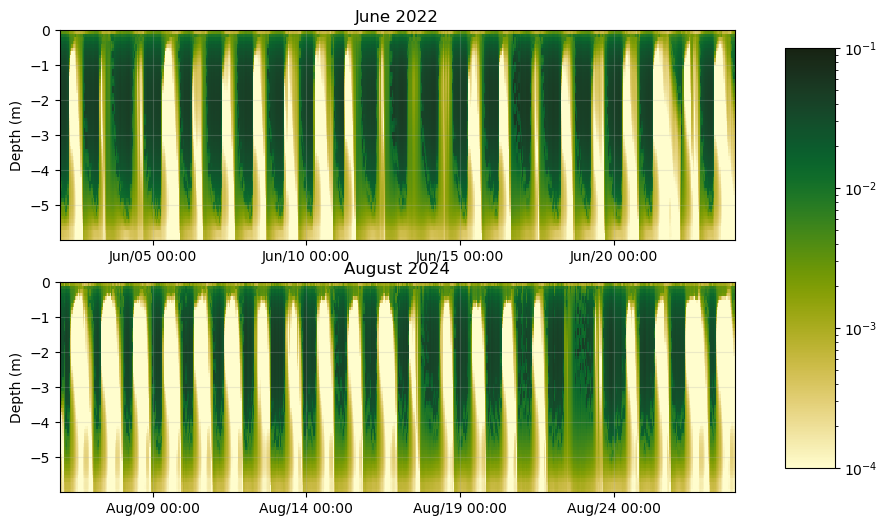

In [122]:
fig, axs = plt.subplots(figsize=(10, 6), nrows=2, sharey=True, sharex=False)

c = axs[0].pcolormesh(m2022.dates,-m2022.ds.z, m2022.ds['Kz'].values.T,   cmap=cmo.cm.speed, norm=mpl.colors.LogNorm(vmin=10e-5, vmax=10e-2))#, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
c = axs[1].pcolormesh(m2024.dates,-m2024.ds.z, m2024.ds['Kz'].values.T,   cmap=cmo.cm.speed, norm=mpl.colors.LogNorm(vmin=10e-5, vmax=10e-2)) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)

format_date_ax(axs[0], days=5)
format_date_ax(axs[1], days=5)

cb = add_colorbar(fig, c)
axs[0].set_title('June 2022')
axs[1].set_title('August 2024')
axs[0].set_ylabel('Depth (m)')
axs[1].set_ylabel('Depth (m)')

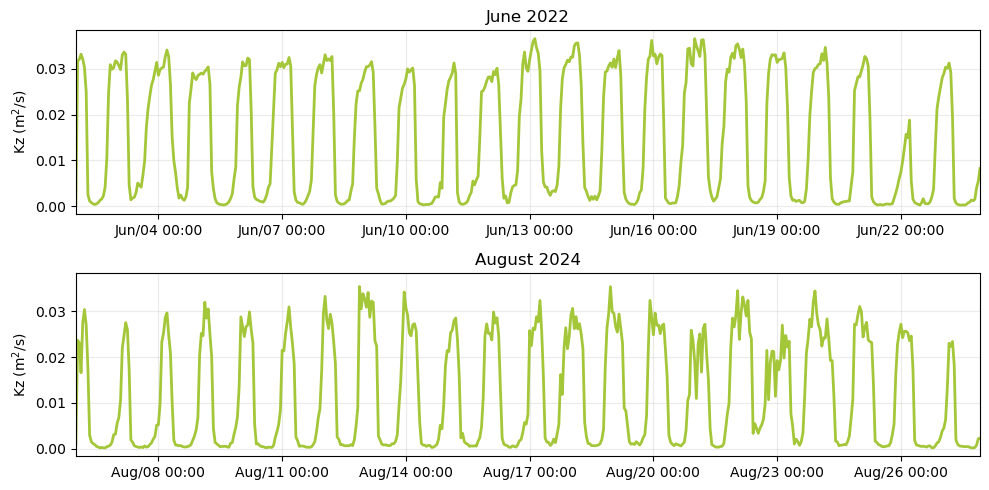

In [ ]:
fig, axs = plt.subplots(figsize=(10, 5), nrows=2, sharey=True, sharex=False)

# Compare diffusivity 
alg = m2022.ds.Kz.sel(z=slice(2, 0)) 
kz_av = kz.mean(dim="z") 

axs[0].plot(m2022.dates, kz_av, color=colors[0], label='June 2022', linewidth=2)

kz = m2024.ds.Kz.sel(z=slice(2, 0)) 
kz_av = kz.mean(dim="z") 

axs[1].plot(m2024.dates, kz_av, color=colors[0], label='June 2022', linewidth=2)

axs[0].set_title('June 2022')
axs[1].set_title('August 2024')

axs[0].set_xlim(m2022.dates[0], m2022.dates[-1])
axs[1].set_xlim(m2024.dates[0], m2024.dates[-1])
for ax in axs: 
    ax.set_ylabel('Kz (m$^2$/s)')
    ax.grid(alpha=0.25)
    format_date_ax(ax, days=3)

plt.tight_layout()


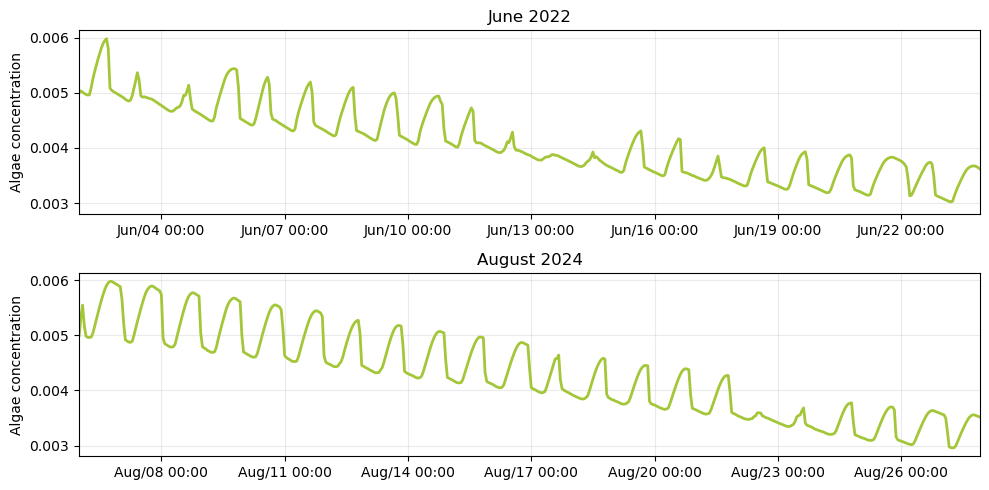

In [129]:
fig, axs = plt.subplots(figsize=(10, 5), nrows=2, sharey=True, sharex=False)

# Compare algae 
alg = m2022.ds.algae1.sel(z=slice(5, 0)) 
alg = alg.mean(dim="z") 

axs[0].plot(m2022.dates, alg, color=colors[0], label='June 2022', linewidth=2)

alg = m2024.ds.algae1.sel(z=slice(5, 0)) 
alg = alg.mean(dim="z") 

axs[1].plot(m2024.dates, alg, color=colors[0], label='June 2022', linewidth=2)

axs[0].set_title('June 2022')
axs[1].set_title('August 2024')

axs[0].set_xlim(m2022.dates[0], m2022.dates[-1])
axs[1].set_xlim(m2024.dates[0], m2024.dates[-1])
for ax in axs: 
    ax.set_ylabel('Algae concentration')
    ax.grid(alpha=0.25)
    format_date_ax(ax, days=3)

plt.tight_layout()


(np.float64(19948.208333333332), np.float64(19948.916666666668))

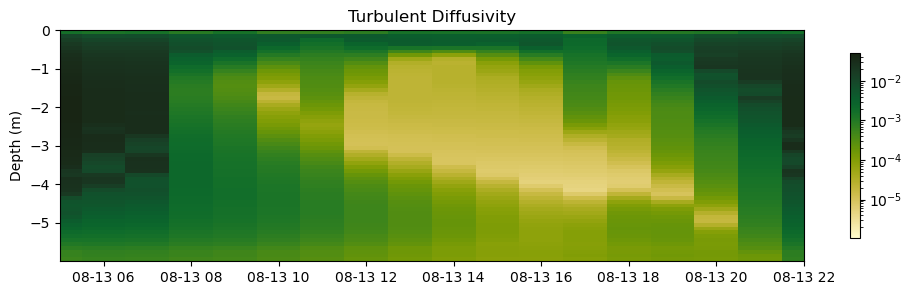

In [125]:
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot(111)
c = ax.pcolormesh(m2024.dates, -m2024.ds.z, m2024.ds['Kz'].values.T ,  cmap=cmo.cm.speed, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
# c = ax.contourf(dates, -model.z, model['Kz'].values.T , levels=20, cmap=cmo.cm.speed_r, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
plt.colorbar(c, shrink=0.8)
# format_date_ax(ax, days=1)
plt.title('Turbulent Diffusivity')
ax.set_ylabel('Depth (m)')
ax.set_xlim(pd.to_datetime("August 13, 2024 05:00"), pd.to_datetime("August 13, 2024 22:00"))


(np.float64(19158.208333333332), np.float64(19163.916666666668))

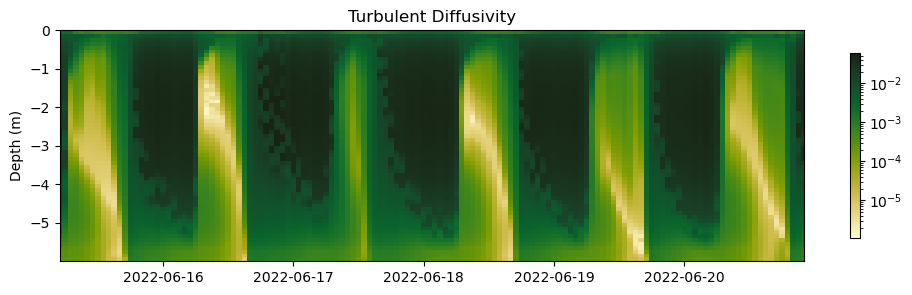

In [126]:
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot(111)
c = ax.pcolormesh(m2022.dates, -m2022.ds.z, m2022.ds['Kz'].values.T ,  cmap=cmo.cm.speed, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
# c = ax.contourf(dates, -model.z, model['Kz'].values.T , levels=20, cmap=cmo.cm.speed_r, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
plt.colorbar(c, shrink=0.8)
# format_date_ax(ax, days=1)
plt.title('Turbulent Diffusivity')
ax.set_ylabel('Depth (m)')
ax.set_xlim(pd.to_datetime("June 15, 2022 05:00"), pd.to_datetime("June 20, 2022 22:00"))

In [ ]:
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot(111)
c = ax.pcolormesh(m2024.dates, -m2024.ds.z, m2024.ds['Kz'].values.T ,  cmap=cmo.cm.speed, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
plt.colorbar(c, shrink=0.8)
# format_date_ax(ax, days=1)
plt.title('Turbulent Diffusivity')
ax.set_ylabel('Depth (m)')
ax.set_xlim(pd.to_datetime("August 11, 2024 05:00"), pd.to_datetime("August 18, 2024 22:00"))

In [127]:
ws = 1.38e-4
z = -model.z.values
time_scale = z*ws 
print(time_scale)


NameError: name 'model' is not defined

(np.float64(19948.208333333332), np.float64(19948.916666666668))

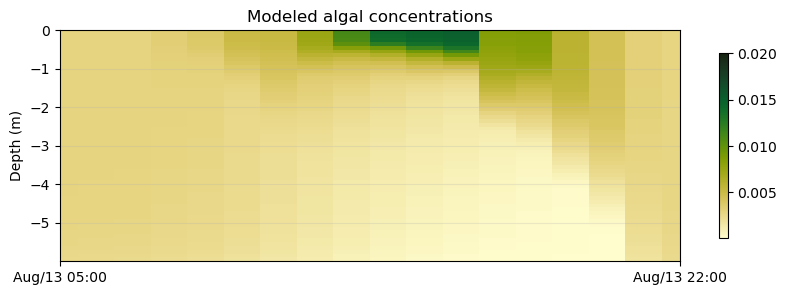

In [ ]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(111)
c = ax.pcolormesh(dates, -model.z, model['algae1'].values.T ,  cmap=cmo.cm.speed, vmax=0.02) #, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
# c = ax.contourf(dates, -model.z, model['algae1'].values.T , levels=50, cmap=cmo.cm.algae, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
plt.colorbar(c, shrink=0.8)
format_date_ax(ax, days=3)
plt.title('Modeled algal concentrations')
ax.set_ylabel('Depth (m)')
ax.set_xlim(pd.to_datetime("August 13, 2024 05:00"), pd.to_datetime("August 13, 2024 22:00"))


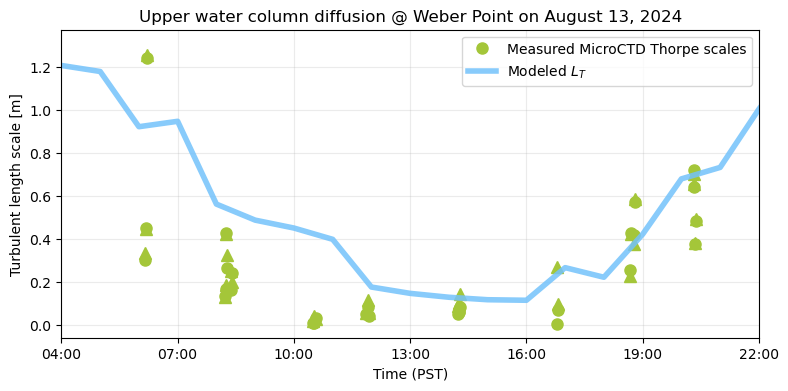

In [ ]:
fig = plt.figure(figsize=(9,4))
ax = plt.gca()

date = "aug_13_2024"

##### Weber Point

# Take surface layer 
t = pd.to_datetime(surface_data.time.values)

L1 = np.nanmean(surface_data.thorpe1, axis=1)
L2 = np.nanmean(surface_data.thorpe2, axis=1)

ax.plot(t, L1, 'o', color=colors[0], markersize=8, label="Measured MicroCTD Thorpe scales")
ax.plot(t, L2, '^', color=colors[0], markersize=8)

modL = model.L.sel(z=slice(4, 0)) 
modL = modL.mean(dim="z") # np.nanmean(kz2.values, axis=0)
ax.plot(dates, modL, linewidth=4, alpha=0.85, color=colors[1], label="Modeled $L_T$")


ax.set_xlim(pd.to_datetime("August 13, 2024 04:00"), pd.to_datetime("August 13, 2024 22:00"))
# format the dateimte axis with mdates
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.grid(alpha=0.25, which="both")
ax.set_ylabel("Turbulent length scale [m]")
ax.set_xlabel("Time (PST)")
ax.legend()
# ax.set_ylim(1e-5, 1e-1)
# ax.set_yscale('log')
ax.set_title("Upper water column diffusion @ Weber Point on August 13, 2024")
plt.show()



<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\k'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_1416408/1179946942.py:3: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(t, np.sqrt(1/k1), 'o', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
/tmp/ipykernel_1416408/1179946942.py:4: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(t, np.sqrt(1/k2), '^', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
/tmp/ipykernel_1416408/1179946942.py:5: SyntaxWarning: invalid escape sequence '\k'
  ax2.plot(dates, 1/kz_av, linewidth=4, alpha=0.5, color=colors[1], label="One-dimension modeled $\kappa$")


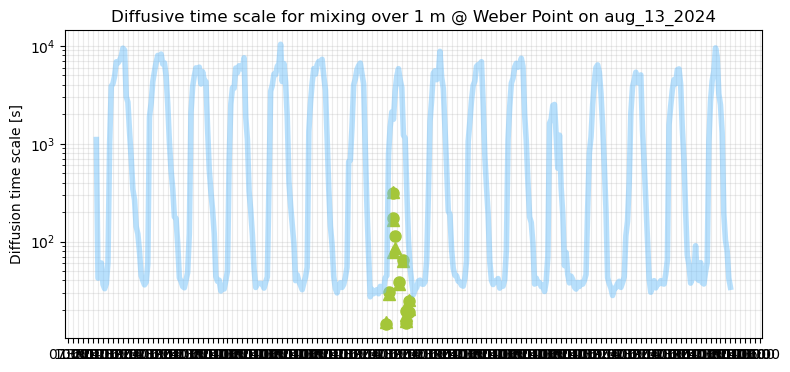

In [ ]:
fig2 = plt.figure(figsize=(9,4))
ax2 = plt.gca()
ax2.plot(t, np.sqrt(1/k1), 'o', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
ax2.plot(t, np.sqrt(1/k2), '^', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
ax2.plot(dates, 1/kz_av, linewidth=4, alpha=0.5, color=colors[1], label="One-dimension modeled $\kappa$")

# ax2.hlines(1/(diatom), t[0], t[-1], color=colors[2], label="1.4e-5 m/s", linestyle="--")
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.grid(alpha=0.25, which="both")
# ax2.set_xlim(dates[175], dates[220])
ax2.set_yscale('log')
ax2.set_ylabel("Diffusion time scale [s]")
ax2.set_ylabel("Diffusion time scale [s]")
ax2.set_title("Diffusive time scale for mixing over 1 m @ Weber Point on %s" % date)
fig.savefig("aug_27.png")